Step 09 - 2D Laplace Equation

Here, the goal was to understand the concept of an iterative solver, we longer carry out iterations in time-steps but we keep on iterating until an equillibrium state is reached (we approximate the equillibrium state by making an initial guess then solve with boundary conditions, then keep on iterating till the current solution and its preceeding one are close enough (in simple terms CONVERGE)). The Laplace Equation is widely regarded as the steady (equillibrium) state equation (because it naturally smoothens solutions; every solution depends on four neighbouring solutions).

Also i utilised writing cfd codes in functions so as to make the code modular and reusable

In [11]:
# importing a 3D viewer
from mpl_toolkits.mplot3d import Axes3D

# importing the required libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [12]:
# creating a function for plotting our solution
def plot_solution(x, y, p): # it takes in three arguments, the x-vector, y-vector and the p(solution) matrix producing a 3D projection plot
    fig = plt.figure(figsize=(11, 7), dpi=100) # creating a figure object with a specified size and resolution
    ax = fig.add_subplot(projection='3d') # adding a subplot to the figure with 3D projection
    X, Y = np.meshgrid(x, y)
    surf = ax.plot_surface(X, Y, p[:], rstride=1, cstride=1, cmap=cm.viridis, linewidth=0, antialiased=False) # plotting the surface using the x, y and p matrices with a colormap
    
    ax.set_xlim(0, 2) # setting the limits for the x-axis
    ax.set_ylim(0, 1) # setting the limits for the y-axis
    ax.view_init(30, 225) # setting the viewing angle for the 3D plot
    ax.set_xlabel('X-axis') # labeling the x-axis
    ax.set_ylabel('Y-axis') # labeling the y-axis

In [13]:
# creating the laplace function
def laplace2d(p, y, dx, dy, llnorm_target): # it takes in five arguments, the p(solution) matrix, y-vector, dx (spatial step in x-direction), dy (spatial step in y-direction) and llnorm_target (the target value for the L2 norm of the difference between successive iterations)

    llnorm = 1 # initializing the L2 norm to 1
    pn = np.empty_like(p) # creating an empty array to store the previous iteration's solution
    while llnorm > llnorm_target: # while the L2 norm is greater than the target value
        pn = p.copy() # creating a copy of the current solution matrix
        p[1:-1, 1:-1] = ((dy**2 * (pn[1:-1, 2:] + pn[1:-1, 0:-2]) + dx**2 * (pn[2:, 1:-1] + pn[0:-2, 1:-1])) / (2 * (dx**2 + dy**2))) # updating the solution matrix using the finite difference method
        
        # applying boundary conditions after each iteration
        p[:, -1] = y # setting the right boundary to y
        p[:, 0] = 0 # setting the left boundary to 0
        p[-1, :] = p[-2, :] # setting the top boundary to be equal to the second last row
        p[0, :] = p[1, :] # setting the bottom boundary to be equal to the second row
        
        llnorm = (np.sum(np.abs(p[:]) - np.abs(pn[:])) / np.sum(np.abs(pn[:]))) # calculating the L2 norm of the difference between successive iterations

    return p # returning the final solution matrix

In [14]:
# variables declaration
nx = 31 # number of grid points in the x-direction
ny = 31 # number of grid points in the y-direction
dx = 2 / (nx - 1) # spatial step in the x-direction
dy = 1 / (ny - 1) # spatial step in the y-direction


# applying initial conditions
p = np.zeros((ny, nx)) # creating a 2D array of zeros for

#plotting aids
x = np.linspace(0, 2, nx) # creating a vector of x-coordinates
y = np.linspace(0, 1, ny) # creating a vector of y-coordinates

# applying boundary conditions before the iterationS
p[:, -1] = y # setting the right boundary to y
p[:, 0] = 0 # setting the left boundary to 0
p[-1, :] = p[-2, :] # setting the top boundary to be equal to the second last row
p[0, :] = p[1, :] # setting the bottom boundary to be equal to the second row


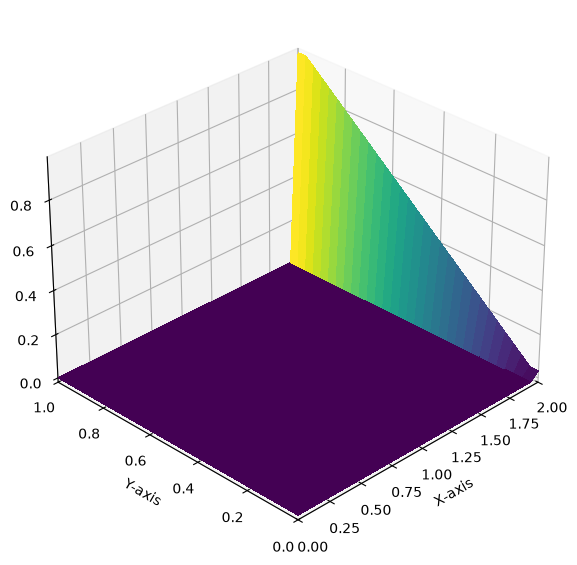

In [15]:
# plotting the initial conditions
plot_solution(x, y, p) # calling the plot_solution function to visualize the initial conditions